ID list generation based on progression status: CN_stable, CN_MCI, MCI_stable, and MCI_AD.

In [1]:
import pandas as pd
import ast

# find # count for each subgroup 
def stat(visit_num):
    global sum
    cn= 0
    cn_mci= 0
    mci= 0
    mci_ad = 0
    file_path_CN = 'AD-Early-Prediction/datasets/Dataset_5/' + str(visit_num) + 'visit_CN_MCI.csv'
    file_path_MCI = 'AD-Early-Prediction/datasets/Dataset_5/' + str(visit_num) + 'visit_MCI_AD.csv'

    # path deviation for 5 visit to exclude expanded datasets
    if (visit_num==5):
        file_path_CN = 'AD-Early-Prediction/datasets/Dataset_5/original_5visit_CN_MCI.csv'
        file_path_MCI = 'AD-Early-Prediction/datasets/Dataset_5/original_5visit_MCI_AD.csv'

    csv_cn=pd.read_csv(file_path_CN)
    csv_mci=pd.read_csv(file_path_MCI)

    # split IDs into two groups based on progressor status
    for i in range(0, len(csv_cn)):
        if (csv_cn.iloc[i,1]==0):
            cn_list.append(csv_cn.iloc[i,0])
            cn+=1
        else: 
            cn_mci_list.append(csv_cn.iloc[i,0])
            cn_mci+=1

    for i in range(0, len(csv_mci)):
        if (csv_mci.iloc[i,1]==0):
            mci_list.append(csv_mci.iloc[i,0])
            mci+=1
        else: 
            mci_ad_list.append(csv_mci.iloc[i,0])
            mci_ad+=1

    print('For '+ str(visit_num)+' visits group:')
    print('CN = '+str(cn))
    print('CN_MCI = '+str(cn_mci))
    print('MCI = '+str(mci))
    print('MCI_AD = '+str(mci_ad))

    sum = cn + cn_mci + mci + mci_ad + sum
    # find_interval(l)


# main lines

cn_list= list()
cn_mci_list= list()
mci_list= list()
mci_ad_list= list()

# all individuals count
sum = 0

# 2-5 visits
for a in range(2,6):
    stat(a)

# save each group's ID list as text files
# with open("CN_list.txt", "w") as file:
#     file.write("\n".join(cn_list))

# with open("CN_MCI_list.txt", "w") as file:
#     file.write("\n".join(cn_mci_list))

# with open("MCI_list.txt", "w") as file:
#     file.write("\n".join(mci_list))

# with open("MCI_AD_list.txt", "w") as file:
#     file.write("\n".join(mci_ad_list))

print(sum)


For 2 visits group:
CN = 998
CN_MCI = 80
MCI = 217
MCI_AD = 218
For 3 visits group:
CN = 556
CN_MCI = 36
MCI = 84
MCI_AD = 205
For 4 visits group:
CN = 545
CN_MCI = 21
MCI = 36
MCI_AD = 190
For 5 visits group:
CN = 370
CN_MCI = 13
MCI = 10
MCI_AD = 110
3689


Demographics analyzer

In [ ]:
import numpy as np
import pandas as pd
import math

# format print
def p(des, count, total):
    print(des + ':  '+ str(count)+'  |  '+str(round(100.0*count/total, 1 ))+ '%')

def find(id, df):
    if not (df[df['ID']==id].empty):
        return df[df['ID']==id]
    print("\nERROR--ID NOT FOUND: "+ id + '\n')

# input: a list of ID and a complete dataset df
def analyze(l, df):
    s = len(l)

    # age sum
    a=0
    # age groups counts
    age51 = 0 # 51-60
    age61 = 0
    age71 = 0
    age81 = 0 # 81-90

    # sex
    m = 0
    f = 0

    # RACE
    white = 0
    black = 0
    ai = 0
    nh = 0
    asian = 0
    other = 0

    # HISPANIC
    hispanic = 0
    not_hispanic = 0

    # comorbidities
    alcohol = 0
    heart_attack = 0
    atrial_fibrillation = 0
    diabetes = 0
    hypercholesteromia = 0
    hypertension = 0
    vb12 = 0
    depression = 0
    anxiety = 0
    trauma = 0

    # APOE
    e1 = 0
    e2 = 0

    for i in l:
        row = find(i, df)

        # safe
        if (row is None):
            continue

        # AGE
        age = int(row.iloc[0]['age'])
        a+=age
        if age<51:
            skip=''
        elif age<61:
            age51+=1
        elif age<71:
            age61+=1
        elif age<81:
            age71+=1
        elif age<91:
            age81+=1
        
        # sex
        sex = int(row.iloc[0]['SEX'])
        if sex==1:
            m+=1
        elif sex==2:
            f+=1

        # RACE
        if not (math.isnan(row.iloc[0]["RACE"])):
            race= int(row.iloc[0]['RACE'])
            if race==1:
                white+=1
            elif race==2:
                black+=1
            elif race==3:
                ai+=1
            elif race==4:
                nh+=1
            elif race==5:
                asian+=1
            else: other+=1
        else:
            print("\nwarning: "+i+" has a RACE value of "+str(row.iloc[0]["RACE"])+ '\n')

        # HISPANIC
        if (int(row.iloc[0]['HISPANIC'])==1):
            hispanic+=1
        else: not_hispanic+=1

        # comorbidities
        if (int(row.iloc[0]['ALCOHOL'])==1):
            alcohol+=1
    
        if (int(row.iloc[0]['CVHATT'])==1):
            heart_attack+=1
    
        if (int(row.iloc[0]['CVAFIB'])==1):
            atrial_fibrillation+=1
    
        if (int(row.iloc[0]['DIABETES'])==1):
            diabetes+=1
    
        if (int(row.iloc[0]['HYPERCHO'])==1):
            hypercholesteromia+=1
    
        if (int(row.iloc[0]['HYPERTEN'])==1):
            hypertension+=1
    
        if (int(row.iloc[0]['B12DEF'])==1):
            vb12+=1
    
        if (int(row.iloc[0]['DEPD'])==1):
            depression+=1
    
        if (int(row.iloc[0]['ANX'])==1):
            anxiety+=1
    
        if (int(row.iloc[0]['NACCTBI'])==1):
            trauma+=1

        # APOE
        if (int(row.iloc[0]['NACCNE4S'])==1):
            e1+=1
        
        if (int(row.iloc[0]['NACCNE4S'])==2):
            e2+=1

    # age
    print("average age: " + str(a/s/1.0))
    p("     51-60", age51, s)
    p("     61-70", age61, s)
    p("     71-80", age71, s)
    p("     81-90", age81, s)

    # sex
    p("Male", m, s)
    p("Female", f, s)

    # RACE
    p("     White", white, s)
    p("     Black", black, s)
    p("     American Indians", ai, s)
    p("     Native Hawaiian", nh, s)
    p("     Asian", asian, s)
    p("     Other", other, s)

    # HISPANIC
    p("     Hispanic/Latino", hispanic, s)
    p("     Not Hispanic/Latino", not_hispanic, s)

    # comorbidities
    p("Alcohol", alcohol, s)
    p("Heart attack", heart_attack, s)
    p("Atrial fibrillation", atrial_fibrillation, s)
    p("Diabetes", diabetes, s)
    p("Hypercholesterolemia", hypercholesteromia, s)
    p("Hypertension", hypertension, s)
    p("Vitamin B12 deficiency", vb12, s)
    p("Depression", depression, s)
    p("Anxiety", anxiety, s)
    p("History of traumatic brain injury", trauma, s)

    # APOE 
    p("One ε4 allele", e1, s)
    p("Two ε4 alleles", e2, s)


# Main lines
cn = pd.read_csv('AD-Early-Prediction/datasets/Dataset_pooled/pooled_CN.csv')
mci = pd.read_csv('AD-Early-Prediction/datasets/Dataset_pooled/pooled_MCI_AD.csv')

lt_cn = pd.read_csv('AD-Early-Prediction/datasets/Dataset_pooled/lead_time_CN.csv')
lt_mci = pd.read_csv('AD-Early-Prediction/datasets/Dataset_pooled/lead_time_MCI_AD.csv')

cn_mci_list = cn['ID']
mci_ad_list = mci['ID']
lt_cn_mci_list = lt_cn['ID']
lt_mci_ad_list = lt_mci['ID']

# classifier group
print("CN_MCI group stats:\n")
analyze(cn_mci_list, cn)
print('\n*******************************\n')

print("MCI/AD group stats:\n")
analyze(mci_ad_list, mci)

print('\n*******************************\n')

# lead time group
print("lead time CN_MCI group stats:\n")
analyze(lt_cn_mci_list, lt_cn)
print('\n*******************************\n')

print("lead time MCI/AD group stats:\n")
analyze(lt_mci_ad_list, lt_mci)


CN_MCI group stats:









average age: 71.73043146239023
     51-60:  321  |  12.3%
     61-70:  877  |  33.5%
     71-80:  883  |  33.7%
     81-90:  464  |  17.7%
Male:  873  |  33.3%
Female:  1746  |  66.7%
     White:  2040  |  77.9%
     Black:  474  |  18.1%
     American Indians:  21  |  0.8%
     Native Hawaiian:  1  |  0.0%
     Asian:  62  |  2.4%
     Other:  17  |  0.6%
     Hispanic/Latino:  162  |  6.2%
     Not Hispanic/Latino:  2457  |  93.8%
Alcohol:  12  |  0.5%
Heart attack:  22  |  0.8%
Atrial fibrillation:  161  |  6.1%
Diabetes:  341  |  13.0%
Hypercholesterolemia:  1303  |  49.8%
Hypertension:  1415  |  54.0%
Vitamin B12 deficiency:  78  |  3.0%
Depression:  193  |  7.4%
Anxiety:  103  |  3.9%
History of traumatic brain injury:  251  |  9.6%

*******************************

MCI/AD group stats:





average age: 74.78504672897196
     51-60:  67  |  6.3%
     61-70:  263  |  24.6%
     71-80:  455  |  42.5%
     81-90:  247  |  23.1%
Male:  529  |  49.4%
Femal

Visit intervals for visit-specific cohorts.

In [1]:


import pandas as pd

df = pd.read_csv('investigator_ftldlbd_nacc72.csv', header=0)

def find_interval(id):
    match=df[df['NACCID']==id]
    match=match.sort_values(by=match.columns[11])
    # formula: days between first and last visits / # of visits
    #   /30.0 to convert days to months
    return (int(match.iat[len(match)-1,11])-int(match.iat[0,11]))/(len(match)-1)/30.0

# classifier group
# for visit_num in range(2,6):
#     file_path_CN = 'AD-Early-Prediction/datasets/Dataset_5/' + str(visit_num) + 'visit_CN_MCI.csv'
#     file_path_MCI = 'AD-Early-Prediction/datasets/Dataset_5/' + str(visit_num) + 'visit_MCI_AD.csv'

#     # path deviation for 5 visit to exclude expanded datasets
#     if (visit_num==5):
#         file_path_CN = 'AD-Early-Prediction/datasets/Dataset_5/original_5visit_CN_MCI.csv'
#         file_path_MCI = 'AD-Early-Prediction/datasets/Dataset_5/original_5visit_MCI_AD.csv'
    
#     cn=pd.read_csv(file_path_CN)['ID']
#     mci=pd.read_csv(file_path_MCI)['ID']

#     sum = 0
#     count = len(cn)+len(mci)
#     for x in cn:
#         sum += find_interval(x)
#     for x in mci:
#         sum += find_interval(x)

#     print('For '+ str(visit_num)+' visits group:')
#     print("     visit interval = "+str(sum/count))
#     print("     averaging over "+str(count)+ " samples.")

# lead time group
cn=pd.read_csv('AD-Early-Prediction/datasets/Dataset_pooled/lead_time_CN.csv')['ID']
mci=pd.read_csv('AD-Early-Prediction/datasets/Dataset_pooled/lead_time_MCI_AD.csv')['ID']

sum = 0
count = len(cn)+len(mci)
for x in cn:
    sum += find_interval(x)
for x in mci:
    sum += find_interval(x)

print('For the lead time group:')
print("     visit interval = "+str(sum/count))
print("     averaging over "+str(count)+ " samples.")




C:\Users\lz000\AppData\Local\Temp\ipykernel_7684\3526704087.py:3: DtypeWarning: Columns (20,22,24,26,28,41,44,46,48,51,61,63,65,67,69,71,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,134,156,165,176,179,189,217,220,222,224,226,228,230,232,234,236,238,240,242,244,246,248,250,252,254,256,258,260,262,264,266,268,270,272,382,397,399,401,419,421,423,432,445,454,494,574,605,613,638,674,690,704,707,710,715,727,738,744,746,804,809,810,811,812,820,831,833,835,837,843,904,959,960,961,969,970,971,972,982,1004,1007,1010,1029,1034,1204,1208,1211,1407,1409,1411,1412,1414,1421,1423,1425,1426,1433,1435,1437,1439,1440,1447,1462,1476,1490,1504,1506,1542,1558,1560,1562,1564,1566,1568,1570,1572,1574,1576,1578,1580,1582,1584,1586,1588,1590,1592,1594,1596,1598,1600,1602,1604,1606,1608,1610,1612,1662,1663,1665,1666,1669,1670,1673,1674,1677,1678,1681,1682,1756,1815,1824,1826,1828,1830,1841,1843,1845,1853,1855,1857,1859,1867,1869,1871,1873,1899) have mixed types. Spe

For the lead time group:
     visit interval = 14.754245319089723
     averaging over 1414 samples.


For 2 visits group:
     visit interval = 16.571851362267747
     averaging over 1513 samples.
For 3 visits group:
     visit interval = 15.711675495018303
     averaging over 881 samples.
For 4 visits group:
     visit interval = 15.083654601571277
     averaging over 792 samples.
For 5 visits group:
     visit interval = 14.956317649657606
     averaging over 503 samples.

Variable missingness analysis

In [ ]:
import pandas as pd
import numpy as np

# Longitudinal columns stored as per-visit lists
_LONG_COLS = [
    'NACCBMI', 'NACCMMSE', 'NACCGDS', 'CDRSUM', 'TOBAC30',
    'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE',
    'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL',
    'hearing', 'vision',
    'NACCLIVS', 'COMMUN',
]

# Scalar columns — take the most-recent visit value
_SCALAR_COLS = [
    'SEX', 'EDUC', 'ALCOHOL', 'NACCFAM',
    'CVHATT', 'CVAFIB', 'DIABETES', 'HYPERCHO', 'HYPERTEN',
    'B12DEF', 'DEPD', 'ANX', 'NACCTBI', 'SMOKYRS', 'RACE', 'HISPANIC',
    'NACCNE4S',
]

def long_miss(df):
    miss_rates = pd.Series([np.isnan(eval(arr)).mean() for arr in df])
    return miss_rates.mean(), miss_rates.std()

# MAIN LINES
# lead_cn = pd.read_csv("datasets/Dataset_v2/lead_time_CN.csv")
lead_mci = pd.read_csv("datasets/Dataset_v2/lead_time_MCI_AD.csv")
# pooled_cn = pd.read_csv("datasets/Dataset_v2/pooled_CN.csv")
pooled_mci = pd.read_csv("datasets/Dataset_v2/pooled_MCI_AD.csv")

# grand = pd.concat([lead_cn, lead_mci, pooled_cn, pooled_mci], ignore_index=True)
# grand = pd.concat([lead_cn, pooled_cn], ignore_index=True)
grand = pd.concat([lead_mci, pooled_mci], ignore_index=True)

n_p= grand[grand['Prog_ID']==0]
p = grand[grand['Prog_ID']==1]

missingness = pd.DataFrame(index=[0,1,2,3], columns=["count"]+ _LONG_COLS + _SCALAR_COLS)
missingness['count'][0] = len(n_p)
missingness['count'][2] = len(p)
nan = np.nan

for var in _LONG_COLS:
    # find missingness for np
    mean, std = long_miss(n_p[var])
    missingness[var][0]= mean
    missingness[var][1]= std

    # find missingness for p
    mean, std = long_miss(p[var])
    missingness[var][2]= mean
    missingness[var][3]= std

for var in _SCALAR_COLS:
    # find missingness for np
    miss = (np.isnan(n_p[var]))
    missingness[var][0] = miss.mean()

    # find missingness for p
    miss = (np.isnan(p[var]))
    missingness[var][2] = miss.mean()

# missingness.to_csv("missing_rates_combined.csv", index=False)
# missingness.to_csv("missing_rates_CN.csv", index=False)
missingness.to_csv("missing_rates_MCI_AD.csv", index=False)


C:\Users\lz000\AppData\Local\Temp\ipykernel_16704\685845111.py:44: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  missingness['count'][0] = len(n_p)
C:\Users\lz000\AppData\Local\Temp\ipykernel_16704\685845111.py:45: FutureWarning: ChainedAssi

Visualize missingness

FROM missing_rates_combined.csv:


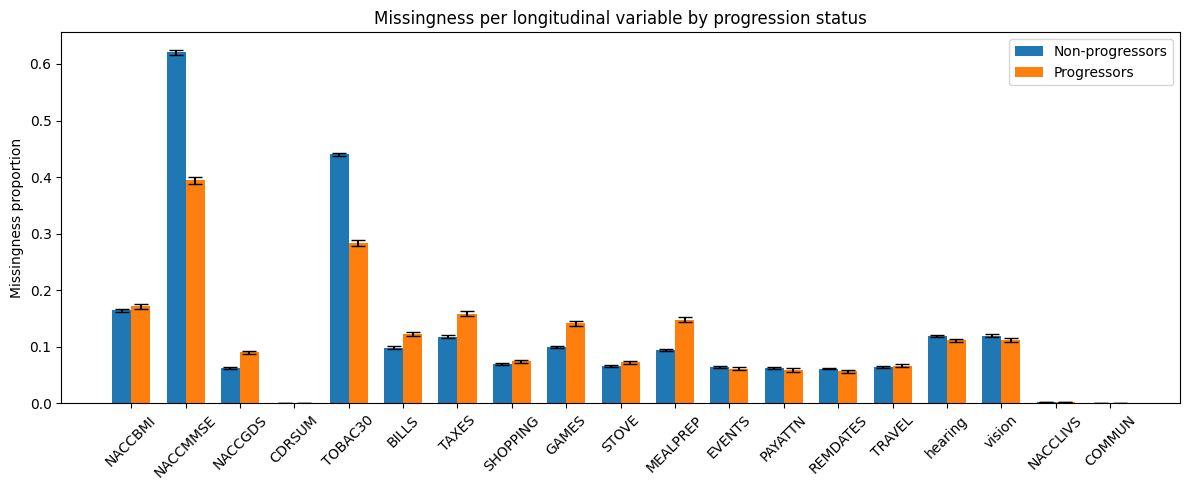

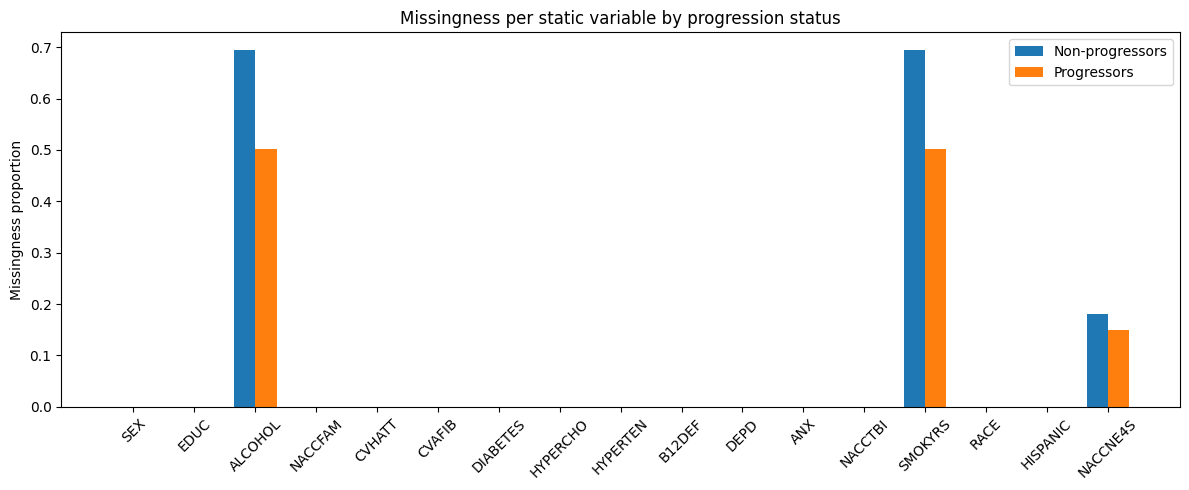

FROM missing_rates_CN.csv:


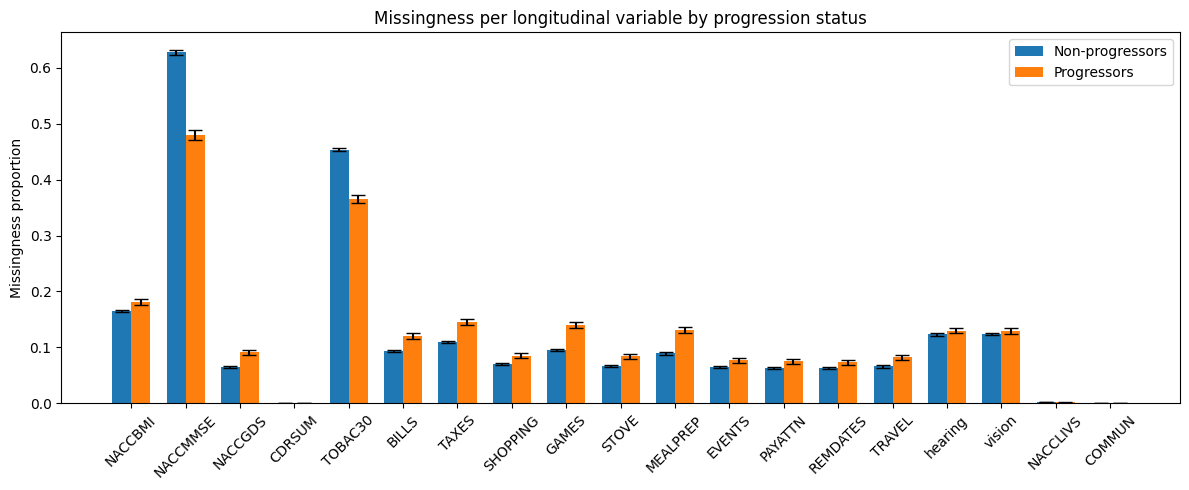

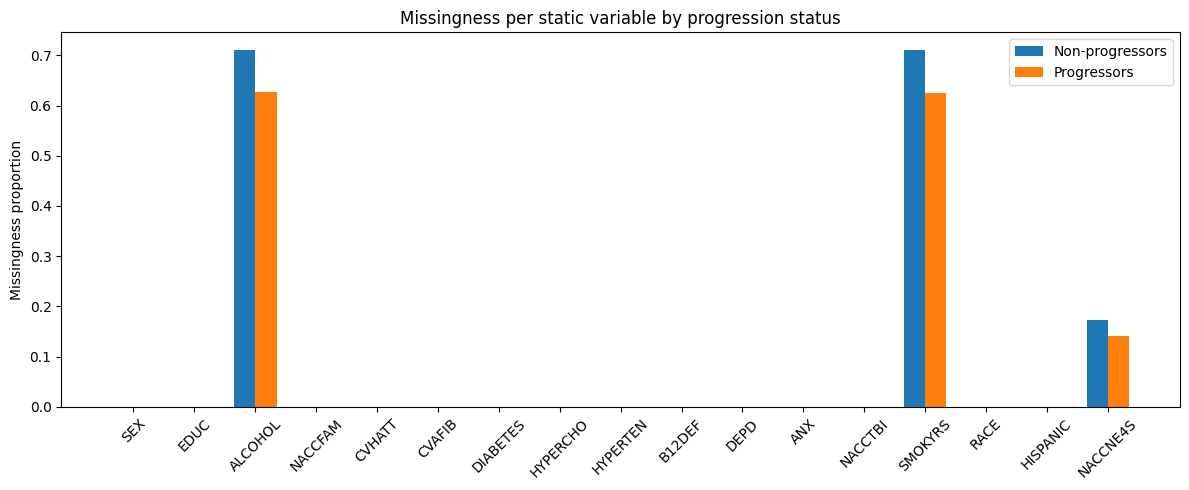

FROM missing_rates_MCI_AD.csv:


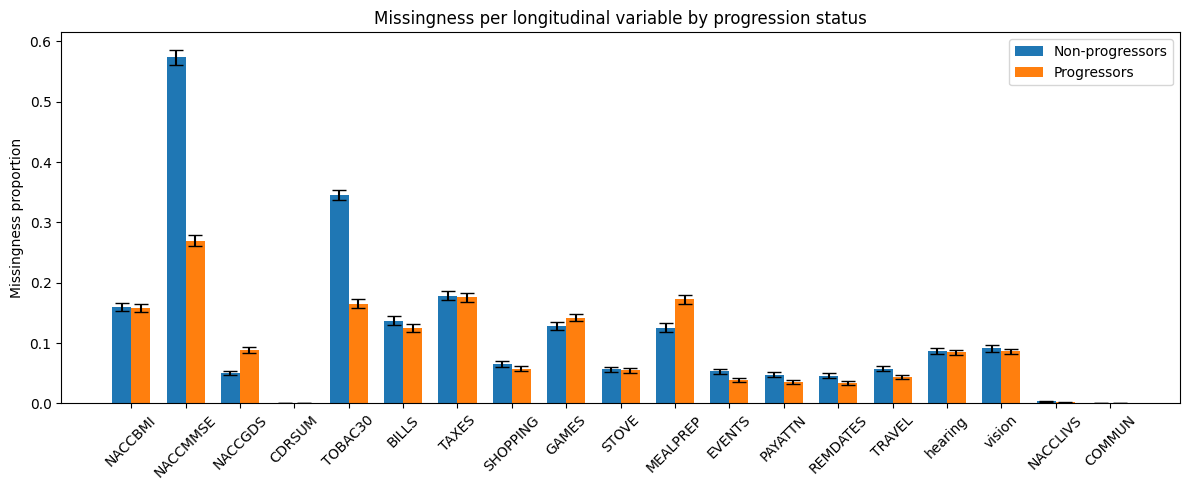

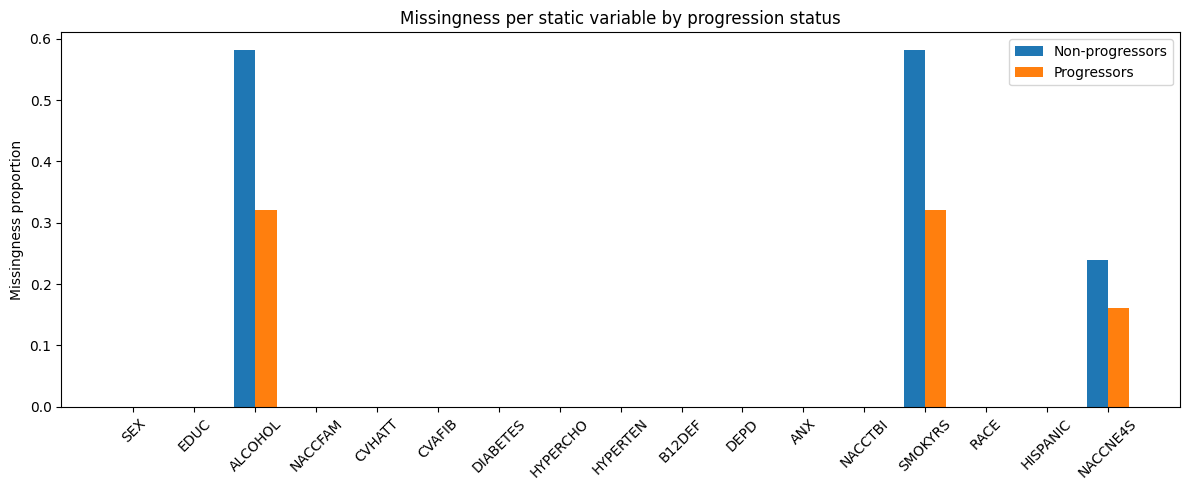

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

paths = ["missing_rates_combined.csv", "missing_rates_CN.csv", "missing_rates_MCI_AD.csv"]
for path in paths:
    print(f"FROM {path}:")
    csv = pd.read_csv(path)
    # Longitudinal columns stored as per-visit lists
    _LONG_COLS = [
        'NACCBMI', 'NACCMMSE', 'NACCGDS', 'CDRSUM', 'TOBAC30',
        'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE',
        'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL',
        'hearing', 'vision',
        'NACCLIVS', 'COMMUN',
    ]

    # Scalar columns — take the most-recent visit value
    _SCALAR_COLS = [
        'SEX', 'EDUC', 'ALCOHOL', 'NACCFAM',
        'CVHATT', 'CVAFIB', 'DIABETES', 'HYPERCHO', 'HYPERTEN',
        'B12DEF', 'DEPD', 'ANX', 'NACCTBI', 'SMOKYRS', 'RACE', 'HISPANIC',
        'NACCNE4S',
    ]

    long_var_count = len(_LONG_COLS)

    # error bar calculation using sd / sqr(sample size)
    sample_size_np_sqr = csv.iloc[0,0] ** 0.5
    stdnp = csv.iloc[1, 1:long_var_count+1]
    errnp = []
    for x in stdnp:
        errnp.append(x/sample_size_np_sqr)

    sample_size_p_sqr = csv.iloc[2,0] ** 0.5
    stdp = csv.iloc[3, 1:long_var_count+1]
    errp = []
    for x in stdp:
        errp.append(x/sample_size_p_sqr)

    x = np.arange(long_var_count)
    width = 0.35

    plt.figure(figsize=(12,5))

    plt.bar(x - width/2, csv.iloc[0, 1:long_var_count+1], width,
            yerr=errnp, capsize=5, label='Non-progressors')

    plt.bar(x + width/2, csv.iloc[2, 1:long_var_count+1], width,
            yerr=errp, capsize=5, label='Progressors')

    plt.xticks(x, _LONG_COLS, rotation=45)
    plt.ylabel("Missingness proportion")
    plt.title("Missingness per longitudinal variable by progression status")
    plt.legend()
    plt.tight_layout()
    plt.show()

    stat_var_count = len(_SCALAR_COLS)
    x = np.arange(stat_var_count)
    width = 0.35

    plt.figure(figsize=(12,5))

    plt.bar(x - width/2, csv.iloc[0, long_var_count+1:long_var_count+1+stat_var_count], width,
            capsize=5, label='Non-progressors')

    plt.bar(x + width/2, csv.iloc[2, long_var_count+1:long_var_count+1+stat_var_count], width,
            capsize=5, label='Progressors')

    plt.xticks(x, _SCALAR_COLS, rotation=45)
    plt.ylabel("Missingness proportion")
    plt.title("Missingness per static variable by progression status")
    plt.legend()
    plt.tight_layout()
    plt.show()

Missingness heatmap

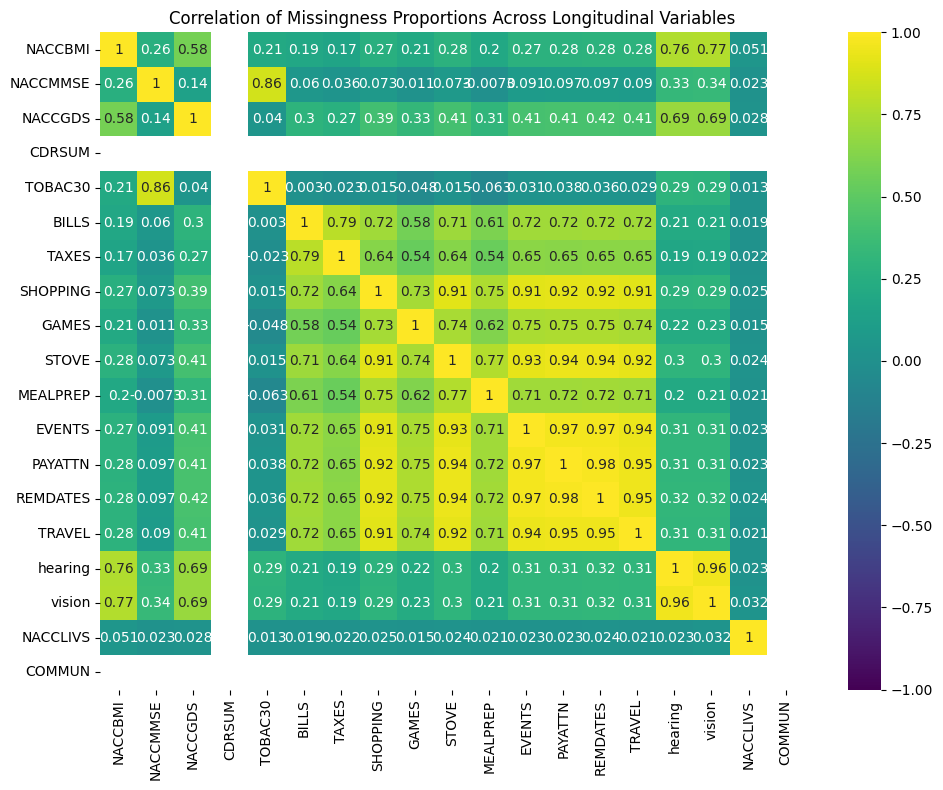

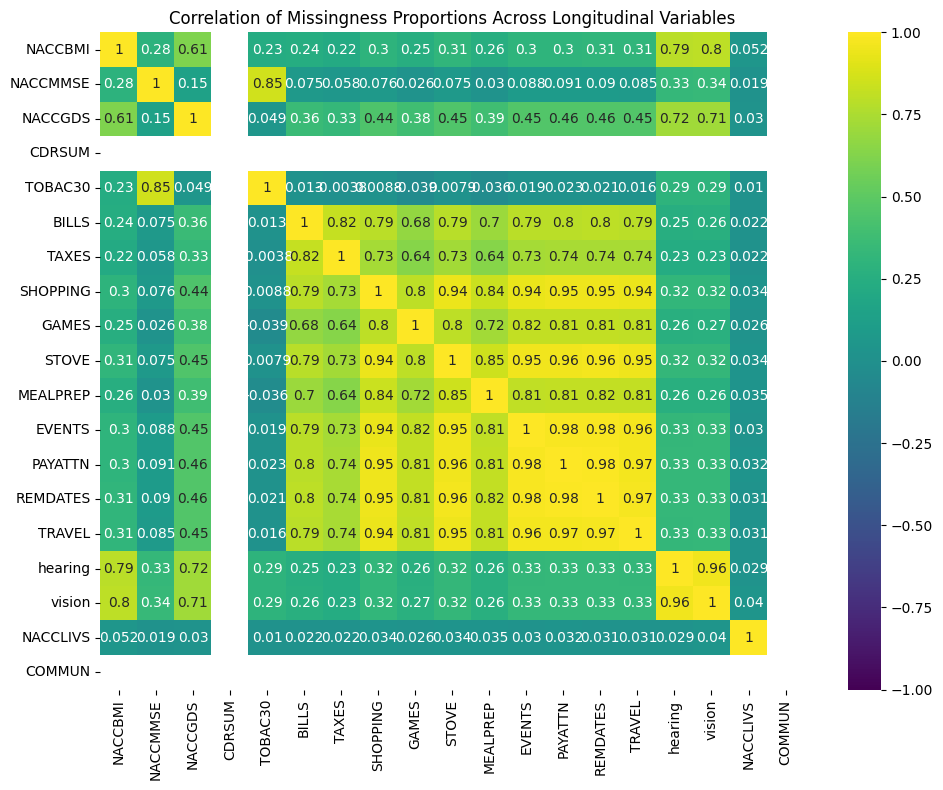

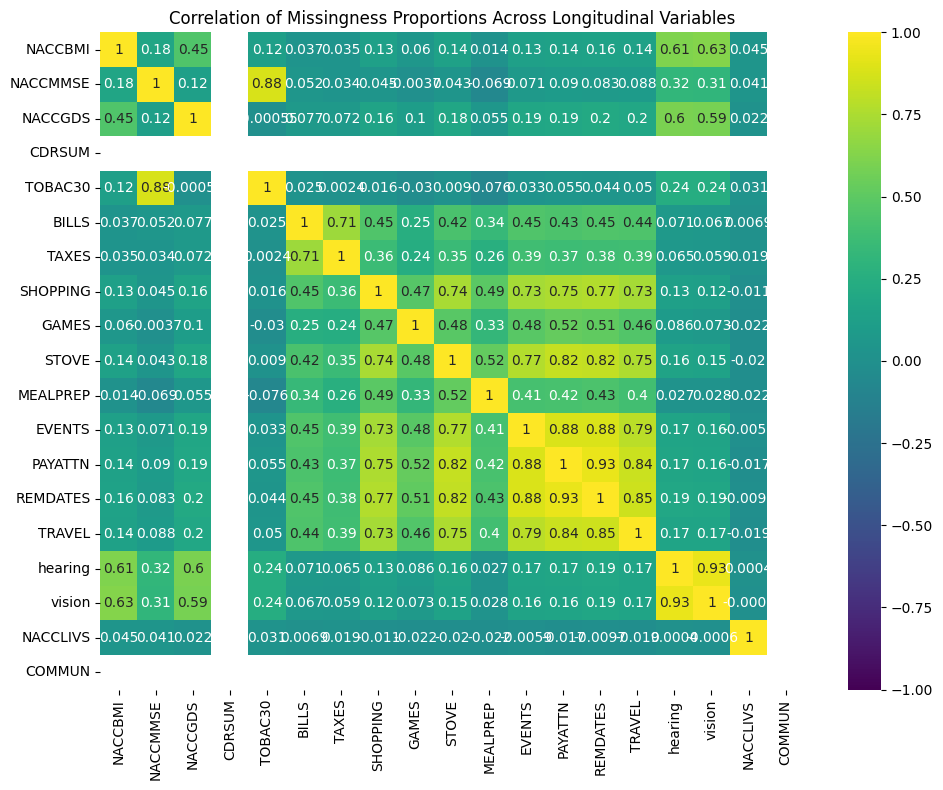

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def proportion_missing(x):
    """Return proportion missing inside a list, or NaN if not a list."""
    if isinstance(x, str): 
        x = eval(x)
    if isinstance(x, list):
        return np.mean(pd.isna(x))
    return np.nan

# Longitudinal columns stored as per-visit lists
longitudinal_cols = [
    'NACCBMI', 'NACCMMSE', 'NACCGDS', 'CDRSUM', 'TOBAC30',
    'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE',
    'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL',
    'hearing', 'vision',
    'NACCLIVS', 'COMMUN',
]
nan = np.nan

lead_cn = pd.read_csv("datasets/Dataset_v2/lead_time_CN.csv")
lead_mci = pd.read_csv("datasets/Dataset_v2/lead_time_MCI_AD.csv")
pooled_cn = pd.read_csv("datasets/Dataset_v2/pooled_CN.csv")
pooled_mci = pd.read_csv("datasets/Dataset_v2/pooled_MCI_AD.csv")

grand = []
grand.append(pd.concat([lead_cn, lead_mci, pooled_cn, pooled_mci], ignore_index=True))
grand.append(pd.concat([lead_cn, pooled_cn], ignore_index=True))
grand.append(pd.concat([lead_mci, pooled_mci], ignore_index=True))

for i in range(3):
    df = grand[i]
    # Create proportion-missing columns
    prop_df = pd.DataFrame({
        col: df[col].apply(proportion_missing)
        for col in longitudinal_cols
    })

    corr = prop_df.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="viridis", vmin=-1, vmax=1)
    plt.title("Correlation of Missingness Proportions Across Longitudinal Variables")
    plt.tight_layout()
    plt.show()

###
# First chart: combined
# Second: CN
# Third: MCI_AD
###

Missingness at each time point for longitudinal variables

C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.088' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]=round(1.0*m.iloc[a,b]/c.iloc[a,b],3)
C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.156' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]=round(1.0*m.iloc[a,b]/c.iloc[a,b],3)
C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.194' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]

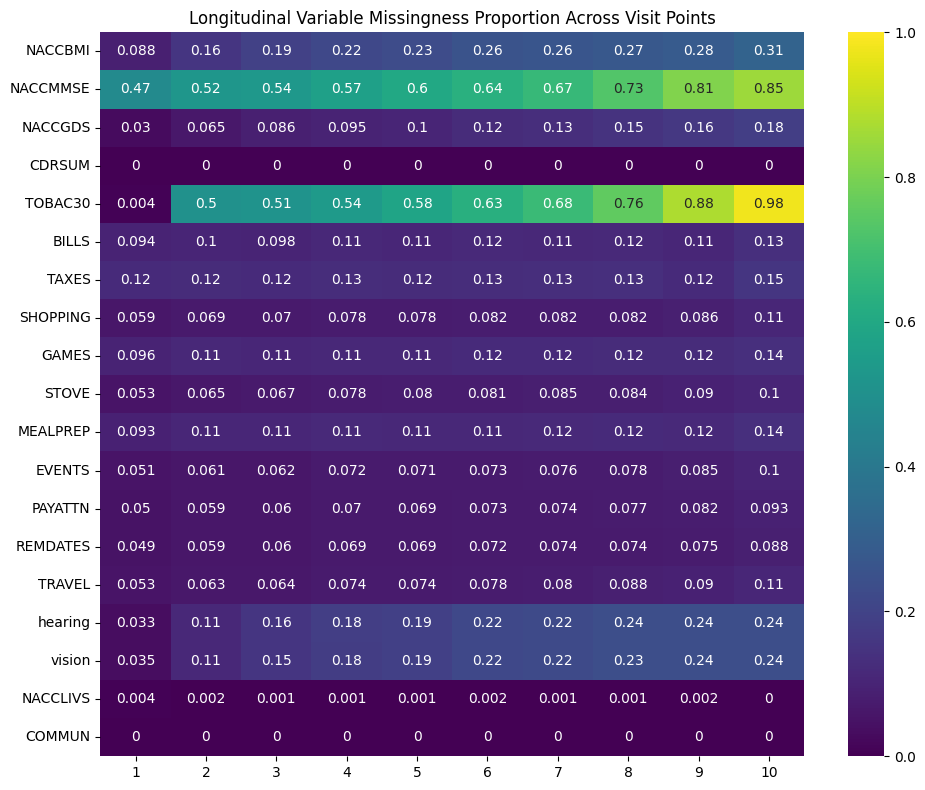

C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.083' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]=round(1.0*m.iloc[a,b]/c.iloc[a,b],3)
C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.156' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]=round(1.0*m.iloc[a,b]/c.iloc[a,b],3)
C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.2' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]=r

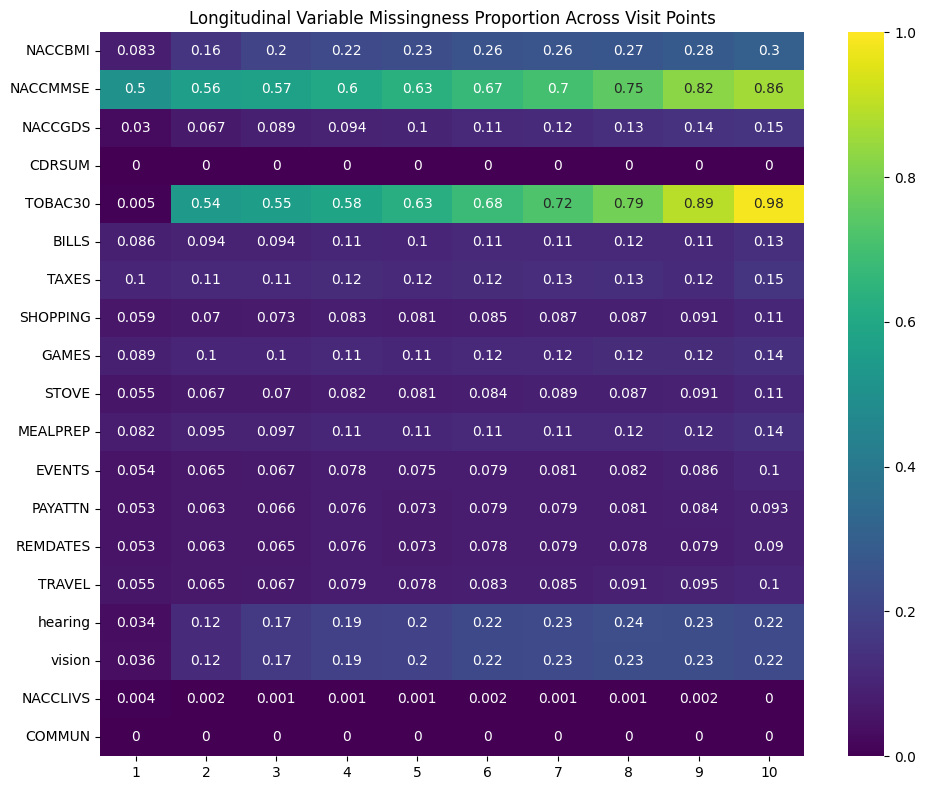

C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.11' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]=round(1.0*m.iloc[a,b]/c.iloc[a,b],3)
C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.155' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]=round(1.0*m.iloc[a,b]/c.iloc[a,b],3)
C:\Users\lz000\AppData\Local\Temp\ipykernel_16312\2422469650.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.163' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  rates.iloc[b,a]=

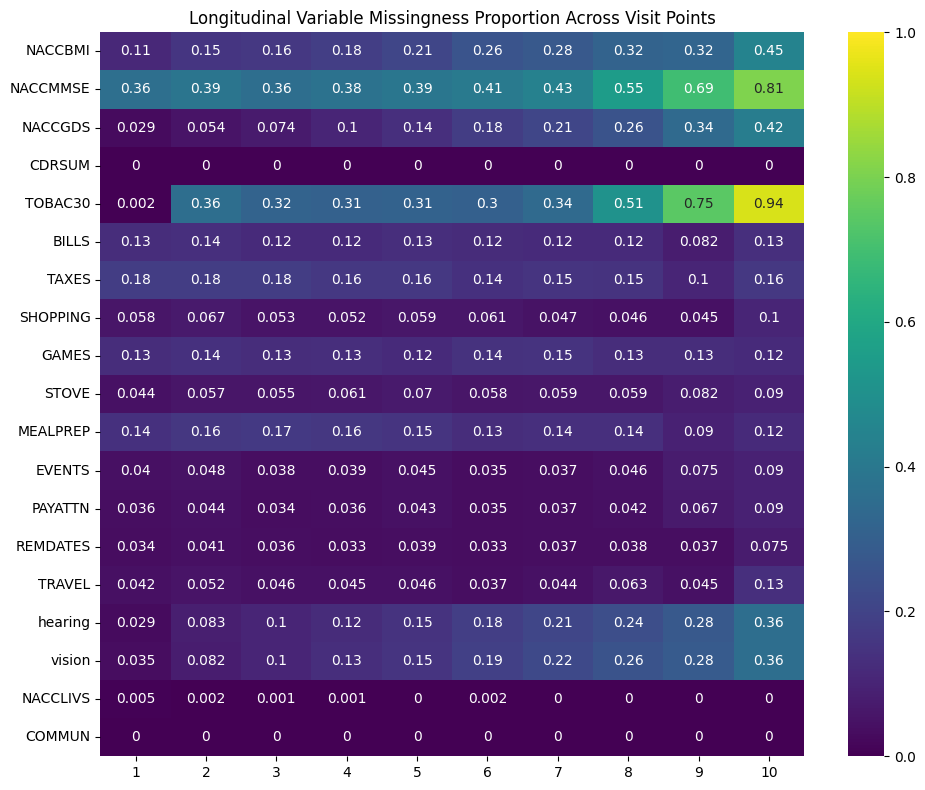

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Longitudinal columns stored as per-visit lists
longitudinal_cols = [
    'NACCBMI', 'NACCMMSE', 'NACCGDS', 'CDRSUM', 'TOBAC30',
    'BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE',
    'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL',
    'hearing', 'vision',
    'NACCLIVS', 'COMMUN',
]
nan = np.nan

lead_cn = pd.read_csv("datasets/Dataset_v2/lead_time_CN.csv")
lead_mci = pd.read_csv("datasets/Dataset_v2/lead_time_MCI_AD.csv")
pooled_cn = pd.read_csv("datasets/Dataset_v2/pooled_CN.csv")
pooled_mci = pd.read_csv("datasets/Dataset_v2/pooled_MCI_AD.csv")

grand = []
grand.append(pd.concat([lead_cn, lead_mci, pooled_cn, pooled_mci], ignore_index=True))
grand.append(pd.concat([lead_cn, pooled_cn], ignore_index=True))
grand.append(pd.concat([lead_mci, pooled_mci], ignore_index=True))

for i in range(3):
    # missing counts
    m = pd.DataFrame(0,index = range(10), columns = longitudinal_cols)
    # total counts
    c = pd.DataFrame(0,index = range(10), columns = longitudinal_cols)
    # missing rates
    rates = pd.DataFrame(0,index = longitudinal_cols, columns = range(1,11))

    def add_miss_count(row):
        v = int(row['n_visits'])
        for col in longitudinal_cols:
            l = []
            if isinstance(row[col], str):
                l = eval(row[col])
            for i in range(v):
                m.at[i, col] += int(np.isnan(l[i]))
                c.at[i, col] += 1

    for r in range(len(grand[i])):
        add_miss_count(grand[i].iloc[r])

    for a in range(10):
        for b in range(len(longitudinal_cols)):
            rates.iloc[b,a]=round(1.0*m.iloc[a,b]/c.iloc[a,b],3)

    rates = rates.apply(pd.to_numeric, errors='coerce')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(rates, annot=True, cmap="viridis", vmin=0, vmax=1)
    plt.title("Longitudinal Variable Missingness Proportion Across Visit Points")
    plt.tight_layout()
    plt.show()
###
# First chart: combined
# Second: CN
# Third: MCI_AD
###